 # Predicción temporal de zonas y horarios de riesgo

In [4]:
from tensorflow import random as tf_random
import random
import numpy as np
import sys
sys.path.append('../')
random.seed(777)
np.random.seed(777)
tf_random.set_seed(777)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error
from src.utils.fechas import rellenar_zona
from src.utils.LSTMPipeline import LSTMPipeline

df = pd.read_html('../data/raw/Estadisticas.ods')[0] # Datos desde 01-01-2023 hasta el 10 de marzo del 2026
print(sys.version)
print(df.shape)
df.head(3)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
(142781, 12)


,Delito,SubDelito,Fecha,Hora,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
0,ASALTO,ARMA BLANCA,2023-01-01,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,VENEZUELA,SAN JOSE,SAN JOSE,MERCED
1,ASALTO,ARMA BLANCA,2023-01-03,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,HOSPITAL
2,ASALTO,ARMA BLANCA,2023-01-03,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,LIMON,SIQUIRRES,SIQUIRRES


## Preprocesamiento general

In [2]:
df['Hora'] = df['Hora'].str.split(':').str[0].astype(int)
df =  df.sort_values(['Fecha', 'Hora'])
df.head(2)

,Delito,SubDelito,Fecha,Hora,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
250,ASALTO,ARMA BLANCA,2023-01-01,0,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,GARABITO,JACO
399,ASALTO,ARMA BLANCA,2023-01-01,0,PERSONA,PEATON [PERSONA],Menor de edad,MUJER,COSTA RICA,SAN JOSE,SAN JOSE,URUCA


A continuacion se agrupan los registros segun zona y hora. De esta manera es posible conocer el total de delitos ocurridos

In [3]:
group_cols = ['Fecha', 'Hora' ,'Provincia']
other_cols = [col for col in df.columns if col not in group_cols]

moda = lambda x: x.value_counts().index[0]

agg_dict = {col: (col, moda) for col in other_cols}
agg_dict['Conteo'] = (other_cols[0], 'count')

df_agrupado = df.groupby(group_cols).agg(**agg_dict).reset_index()
print(df_agrupado.shape)
df_agrupado.head(5)

(48411, 13)


,Fecha,Hora,Provincia,Delito,SubDelito,Victima,SubVictima,Edad,Sexo,Nacionalidad,Canton,Distrito,Conteo
0,2023-01-01,0,ALAJUELA,HURTO,POR CONFIANZA,VIVIENDA,NO APLICA [VIVIENDA],Mayor de edad,HOMBRE,COSTA RICA,ALAJUELA,FORTUNA,5
1,2023-01-01,0,CARTAGO,ASALTO,ARREBATO,PERSONA,OTRO O INDETERMINADO [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,EL GUARCO,SAN ISIDRO,8
2,2023-01-01,0,GUANACASTE,HURTO,POR DESCUIDO,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SANTA CRUZ,TAMARINDO,18
3,2023-01-01,0,HEREDIA,HURTO,POR DESCUIDO,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,HEREDIA,SAN PABLO,8
4,2023-01-01,0,LIMON,HURTO,CARTERISTA,PERSONA,NO APLICA [VIVIENDA],Mayor de edad,HOMBRE,COSTA RICA,MATINA,CAHUITA,9


## Prediccion

### Usando la estructura sugerida

In [4]:
cartago_full = df_agrupado[df_agrupado['Provincia'] == 'CARTAGO'].drop(columns=['Provincia','SubDelito','SubVictima','Distrito'])
cartago_full = rellenar_zona(cartago_full)

test_size = 240 # 30 dias
df_train_test = cartago_full.iloc[:-test_size]
ultimos_30d = cartago_full.iloc[-test_size:]

indice_corte = int(len(df_train_test) * 0.8)

df_train = df_train_test.iloc[:indice_corte]
df_test = df_train_test.iloc[indice_corte:]

df_train.head(3)

,Fecha,Hora,Delito,Victima,Edad,Sexo,Nacionalidad,Canton,Conteo
0,2023-01-01,0,ASALTO,PERSONA,Mayor de edad,HOMBRE,COSTA RICA,EL GUARCO,8
1,2023-01-01,3,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,0
2,2023-01-01,6,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,Sin delitos,0


In [5]:
pipeline = LSTMPipeline()
X_train, y_train = pipeline.fit_transform(df_train)
X_test, y_test_scaled = pipeline.transform(df_test)

In [6]:
modelo1 = Sequential([
    LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(50),
    Dropout(0.2),
    Dense(1, activation='softplus')
])

modelo1.compile(optimizer='adam', loss='mae', metrics=['mae'])

early_stop = EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=1
)

history1 = modelo1.fit(
    X_train, y_train,
    epochs=60,
    callbacks=[early_stop],
    validation_data=(X_test, y_test_scaled),
    verbose=0
)

c:\Users\mecag\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 18.


In [7]:
y_pred_scaled = modelo1.predict(X_test)
 
y_test = pipeline.inverse_transform_y(y_test_scaled)
y_pred = pipeline.inverse_transform_y(y_pred_scaled)
 
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(((y_test - y_pred) ** 2).mean())  
 
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MAE:  0.8358
RMSE: 1.1922


In [8]:
X_test, y_test_scaled = pipeline.transform(ultimos_30d)
 
y_pred_scaled = modelo1.predict(X_test)
 
test_30d = pipeline.inverse_transform_y(y_test_scaled)
pred_30d = pipeline.inverse_transform_y(y_pred_scaled)

mae_30d  = mean_absolute_error(test_30d, pred_30d)
rmse_30d = np.sqrt(((test_30d - pred_30d) ** 2).mean())  

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


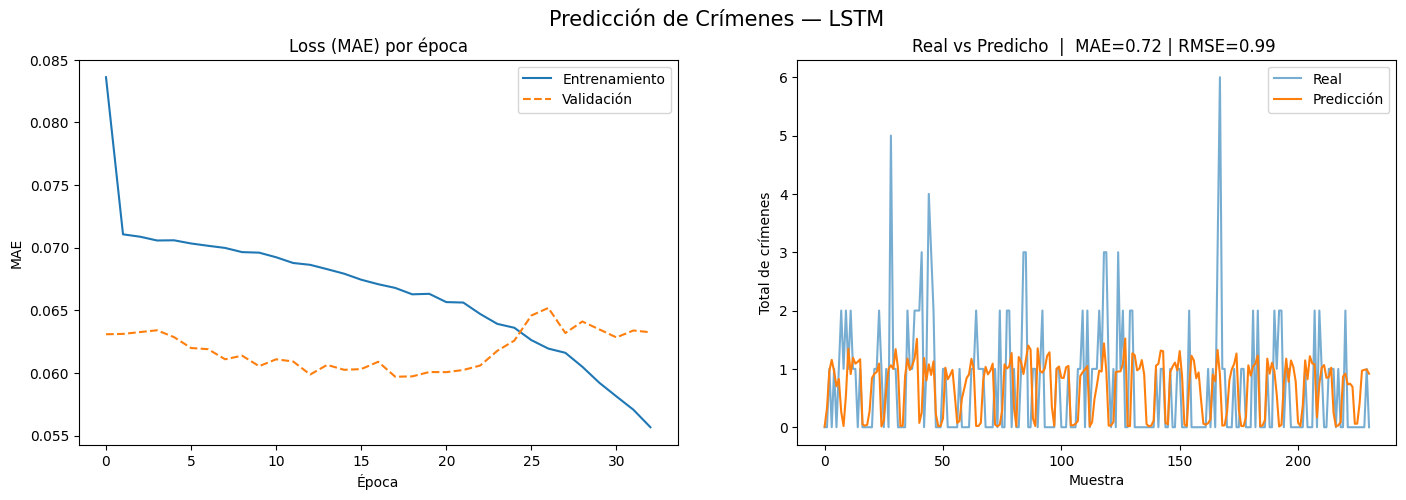

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle("Predicción de Crímenes — LSTM", fontsize=15)

axes[0].plot(history1.history['loss'],     label='Entrenamiento')
axes[0].plot(history1.history['val_loss'], label='Validación', linestyle='--')
axes[0].set_title("Loss (MAE) por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("MAE")
axes[0].legend()

axes[1].plot(test_30d,  label='Real', alpha=0.6)
axes[1].plot(pred_30d,  label='Predicción')
axes[1].set_title(f"Real vs Predicho  |  MAE={mae_30d:.2f} | RMSE={rmse_30d:.2f} ")
axes[1].set_xlabel("Muestra")
axes[1].set_ylabel("Total de crímenes")
axes[1].legend();

### Todas las provincias

In [10]:
provincias = df_agrupado['Provincia'].unique().tolist()
provincias.remove('DESCONOCIDO')
provincias

['ALAJUELA',
 'CARTAGO',
 'GUANACASTE',
 'HEREDIA',
 'LIMON',
 'PUNTARENAS',
 'SAN JOSE']

In [11]:
resultados = {}

for provincia in provincias:
    print(f'Entrenando: {provincia}')
    df_provincia = df_agrupado[df_agrupado['Provincia'] == provincia].drop(columns=['Provincia','SubDelito','SubVictima','Distrito'])
    df_provincia = rellenar_zona(df_provincia)

    full_df = df_provincia.iloc[:-test_size]

    corte = int(len(full_df) * 0.8)

    df_train = full_df.iloc[:corte]
    df_test = full_df.iloc[corte:]

    pipeline = LSTMPipeline()
    X_train, y_train = pipeline.fit_transform(df_train)
    X_test, y_test_scaled = pipeline.transform(df_test)

    modelo_provincia = Sequential([
        LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        LSTM(50),
        Dropout(0.2),
        Dense(1, activation='softplus')
    ])

    modelo_provincia.compile(optimizer='adam', loss='mae', metrics=['mae'])

    early_stop = EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    )

    history1 = modelo_provincia.fit(
        X_train, y_train,
        epochs=60,
        callbacks=[early_stop],
        validation_data=(X_test, y_test_scaled),
        verbose=0
    )

    y_pred_scaled = modelo_provincia.predict(X_test)
 
    y_test = pipeline.inverse_transform_y(y_test_scaled)
    y_pred = pipeline.inverse_transform_y(y_pred_scaled)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(((y_test - y_pred) ** 2).mean())  

    resultados[provincia] = {
        'MAE': mae,
        'RMSE': rmse
    }

    ruta_pipeline = Path(f'../src/models/{provincia}/pipeline.pkl')
    ruta_pipeline.parent.mkdir(parents=True, exist_ok=True)
    pipeline.save(str(ruta_pipeline))

    modelo_provincia.save(f'../src/models/{provincia}/LSTM-{provincia}.keras')

Entrenando: ALAJUELA


c:\Users\mecag\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 11.
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Entrenando: CARTAGO


c:\Users\mecag\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 13.
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Entrenando: GUANACASTE


...

Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 15.
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Entrenando: PUNTARENAS


c:\Users\mecag\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 7.
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Entrenando: SAN JOSE


c:\Users\mecag\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 12.
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


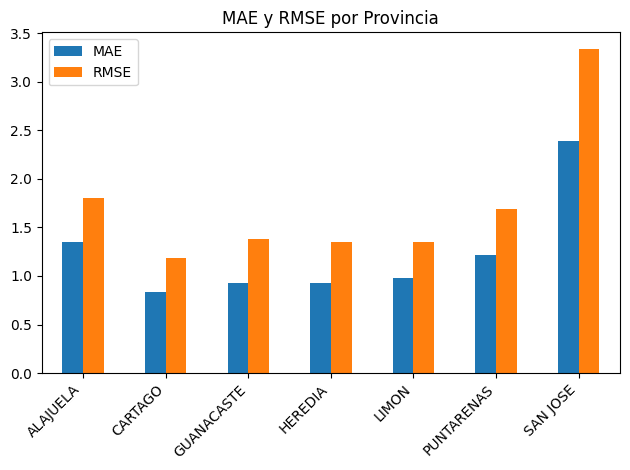

In [12]:
df_resultados = pd.DataFrame(resultados).T

df_resultados.plot(kind='bar', title='MAE y RMSE por Provincia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
ultimos_30d[:9].to_csv('../data/raw/ultimos_9_registros_cartago.csv') # Para usarlos en el ejemplo del otro jupyter

sanjose_full = df_agrupado[df_agrupado['Provincia'] == 'SAN JOSE'].drop(columns=['Provincia','SubDelito','SubVictima','Distrito'])
sanjose_full = rellenar_zona(sanjose_full)

sanjose_full.tail(9).to_csv('../data/raw/ultimos_9_registros_sanjose.csv')